# Product Metrics SQL Case Study

Product question: can a compact SQL warehouse answer the core activation and monetization questions for a product team?
Small SQLite dataset with users, sessions, and orders for funnel, DAU, cohort spend, and country-level conversion queries.

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

conn = sqlite3.connect('../data/product.db')

def run_sql(query):
    return pd.read_sql_query(query, conn)


In [ ]:
run_sql("""
SELECT 'users' as tbl, COUNT(*) as cnt FROM users
UNION ALL
SELECT 'sessions', COUNT(*) FROM sessions
UNION ALL
SELECT 'orders', COUNT(*) FROM orders
""")


,tbl,cnt
0,users,1000
1,sessions,2979
2,orders,351


### Q1 — Signup-to-order funnel conversion
what proportion of signup users placed at least one order?

In [ ]:
run_sql("""
WITH signups AS (SELECT COUNT(*) AS total_users FROM users),
     buyers AS (SELECT COUNT(DISTINCT user_id) AS paying_users FROM orders)
SELECT total_users, paying_users,
       ROUND(1.0 * paying_users / total_users, 3) as conv_rate
FROM signups, buyers
""")


,total_users,paying_users,conv_rate
0,1000,351,0.351


### Q2 — Daily active users & session lengths
average session duration by day.

In [ ]:
run_sql("""
SELECT date(session_start) as session_date,
       COUNT(DISTINCT user_id) as dau,
       ROUND(AVG(duration_sec), 1) as avg_duration_sec
FROM sessions
GROUP BY 1
ORDER BY 1
LIMIT 12
""")


,session_date,dau,avg_duration_sec
0,2024-01-02,2,151.0
1,2024-01-03,1,56.5
2,2024-01-06,2,210.0
3,2024-01-08,2,157.0
4,2024-01-09,6,266.2
5,2024-01-10,3,215.3
6,2024-01-12,5,417.0
7,2024-01-13,6,310.0
8,2024-01-14,4,134.3
9,2024-01-15,6,313.7


### Q3 — Cohort conversion and average spend
how conversion and average spend vary across user signup cohorts.

In [ ]:
cohort_spend = run_sql("""
WITH cohorts AS (
    SELECT user_id, strftime('%Y-%m', signup_date) as cohort_month
    FROM users
),
user_spend AS (
    SELECT user_id, SUM(revenue) as total_spent
    FROM orders
    GROUP BY 1
)
SELECT c.cohort_month,
       COUNT(c.user_id) as total_users,
       COUNT(s.user_id) as paying_users,
       ROUND(AVG(s.total_spent), 2) as avg_spend_per_buyer,
       ROUND(1.0 * COUNT(s.user_id) / COUNT(c.user_id), 3) as cohort_conversion
FROM cohorts c
LEFT JOIN user_spend s ON c.user_id = s.user_id
GROUP BY 1
ORDER BY 1
""")
cohort_spend


,cohort_month,total_users,paying_users,avg_spend_per_buyer,cohort_conversion
0,2024-01,84,31,47.95,0.369
1,2024-02,84,29,50.71,0.345
2,2024-03,84,32,36.90,0.381
3,2024-04,84,34,53.80,0.405
4,2024-05,83,36,38.08,0.434
5,2024-06,83,26,44.80,0.313
6,2024-07,83,33,56.28,0.398
7,2024-08,83,28,50.30,0.337
8,2024-09,83,21,40.38,0.253
9,2024-10,83,27,46.17,0.325


plot cohort size and conversion rate to see if cohort quality changes.

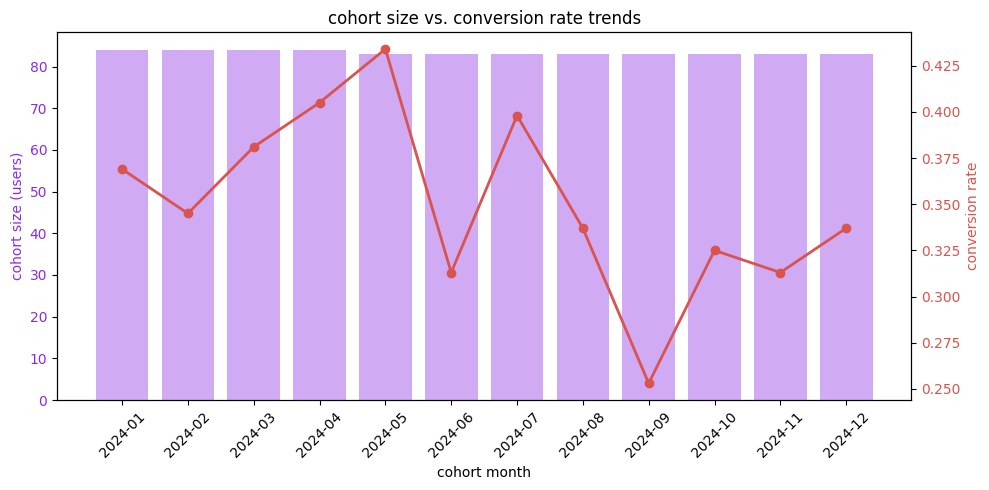

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = '#8a2be2'
ax1.set_xlabel('cohort month')
ax1.set_ylabel('cohort size (users)', color=color)
ax1.bar(cohort_spend['cohort_month'], cohort_spend['total_users'], color=color, alpha=0.4)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

ax2 = ax1.twinx()
color = '#d9534f'
ax2.set_ylabel('conversion rate', color=color)
ax2.plot(cohort_spend['cohort_month'], cohort_spend['cohort_conversion'], color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('cohort size vs. conversion rate trends')
fig.tight_layout()
plt.show()


### Q4 — Top 10% spenders by country
finding the highest spending customers per country using window functions.

In [ ]:
run_sql("""
WITH user_spend AS (
    SELECT u.country, u.user_id, COALESCE(SUM(o.revenue), 0) as spent
    FROM users u
    LEFT JOIN orders o ON u.user_id = o.user_id
    GROUP BY 1, 2
),
ranked AS (
    SELECT *,
           PERCENT_RANK() OVER (PARTITION BY country ORDER BY spent DESC) as pct_rank
    FROM user_spend
)
SELECT country,
       COUNT(*) as top_spenders_count,
       ROUND(AVG(spent), 2) as avg_spend_top_10pct
FROM ranked
WHERE pct_rank <= 0.10
GROUP BY 1
ORDER BY avg_spend_top_10pct DESC
""")


,country,top_spenders_count,avg_spend_top_10pct
0,UK,27,113.35
1,FR,25,108.99
2,US,23,107.38
3,DE,27,80.23


### Q5 — Conversion rate by country
extract conversion rates by country and plot them.

In [ ]:
country_conv = run_sql("""
WITH user_orders AS (
    SELECT DISTINCT user_id FROM orders
),
counts AS (
    SELECT u.country,
           COUNT(DISTINCT u.user_id) as total_users,
           COUNT(DISTINCT uo.user_id) as buyers
    FROM users u
    LEFT JOIN user_orders uo ON u.user_id = uo.user_id
    GROUP BY 1
)
SELECT country, total_users, buyers,
       ROUND(1.0 * buyers / total_users, 3) as conversion_rate
FROM counts
ORDER BY conversion_rate DESC
""")
country_conv


,country,total_users,buyers,conversion_rate
0,FR,242,99,0.409
1,DE,265,89,0.336
2,UK,263,87,0.331
3,US,230,76,0.330


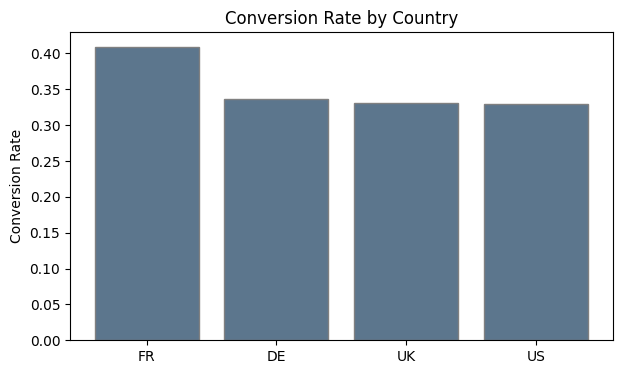

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(country_conv['country'], country_conv['conversion_rate'], color='#5c768d', edgecolor='grey')
plt.title('Conversion Rate by Country')
plt.ylabel('Conversion Rate')
plt.show()


In [ ]:
conn.close()
